# Лабораторная работа №2
## Решение задач кинематики и планирование траектории манипулятора

**Курс:** Моделирование и управление роботами (RMPC)

### Цель работы
Освоить решение прямой и обратной задач кинематики для манипулятора с шестью
степенями свободы (Puma560), построить рабочую зону манипулятора, спланировать
траекторию движения схвата между двумя положениями тремя различными методами
и проанализировать графики положений, скоростей и ускорений в обобщённых
координатах.

### Задание
1. Загрузить модель манипулятора согласно выбранному варианту кинематики.
2. Заполнить все параметры модели робота (как в Лабораторной работе №1).
3. Задать произвольную начальную конфигурацию.
4. Решить прямую задачу кинематики (ПЗК).
5. Построить рабочую зону манипулятора с учётом ограничений суставов.
6. Выбрать конечную точку в рабочей зоне и решить обратную задачу кинематики (ОЗК).
7. Спланировать траекторию между начальным и конечным положением схвата
   как минимум тремя методами планирования.
8. Построить графики положений, скоростей и ускорений в шарнирах.
9. Подготовить отчёт в формате `.ipynb` с подробными комментариями.
10. Сделать выводы по результатам работы.

## 0. Импорт необходимых библиотек

In [1]:
%matplotlib inline
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb
import spatialmath.base as sb
from spatialmath import SE3

np.set_printoptions(precision=4, suppress=True)
print('numpy =', np.__version__)
print('roboticstoolbox =', rtb.__version__)

numpy = 1.26.4
roboticstoolbox = 1.1.1


## 1. Загрузка модели манипулятора Puma560

В качестве варианта кинематики используется промышленный манипулятор
**Unimation Puma 560** — последовательный 6-DOF робот с шестью вращательными
сочленениями (RRRRRR). Модель содержит стандартные DH-параметры,
ограничения суставов и предустановленные конфигурации `qz`, `qr`, `qn`, `qs`.

In [2]:
robot = rtb.models.DH.Puma560()
print(robot)

DHRobot: Puma 560 (by Unimation), 6 joints (RRRRRR), dynamics, geometry, standard DH parameters
┌─────┬────────┬────────┬────────┬─────────┬────────┐
│ θⱼ  │   dⱼ   │   aⱼ   │   ⍺ⱼ   │   q⁻    │   q⁺   │
├─────┼────────┼────────┼────────┼─────────┼────────┤
│  q1 │ 0.6718 │      0 │  90.0° │ -160.0° │ 160.0° │
│  q2 │      0 │ 0.4318 │   0.0° │ -110.0° │ 110.0° │
│  q3 │   0.15 │ 0.0203 │ -90.0° │ -135.0° │ 135.0° │
│  q4 │ 0.4318 │      0 │  90.0° │ -266.0° │ 266.0° │
│  q5 │      0 │      0 │ -90.0° │ -100.0° │ 100.0° │
│  q6 │      0 │      0 │   0.0° │ -266.0° │ 266.0° │
└─────┴────────┴────────┴────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬─────┬──────┬───────┬─────┬──────┬─────┐
│ name │ q0  │ q1   │ q2    │ q3  │ q4   │ q5  │
├──────┼─────┼──────┼───────┼─────┼──────┼─────┤
│   qr │  0° │  90° │ -90°  │  0° │  0°  │  0° │
│   qz │  0° │  0°  │  0°   │  0° │  0°  │  0° │
│   qn │  0° │  45° │  180° │  0° │  45° │  0° │
│   qs │  0° │  0°  │ -90°  │  0° │  0°  │  0° │
└──

## 2. Параметры робота (по Лабораторной работе №1)

Стандартные DH-параметры манипулятора Puma560 (углы в радианах,
линейные размеры в метрах):

| Звено $i$ | $\theta_i$ | $d_i$, м | $a_i$, м | $\alpha_i$ | Пределы $q_i$ |
|:---------:|:----------:|:--------:|:--------:|:----------:|:--------------:|
| 1         | $q_1$      | 0.6718   | 0.0000   | $+\pi/2$   | $[-160°, +160°]$ |
| 2         | $q_2$      | 0.0000   | 0.4318   | $0$        | $[-110°, +110°]$ |
| 3         | $q_3$      | 0.1500   | 0.0203   | $-\pi/2$   | $[-135°, +135°]$ |
| 4         | $q_4$      | 0.4318   | 0.0000   | $+\pi/2$   | $[-266°, +266°]$ |
| 5         | $q_5$      | 0.0000   | 0.0000   | $-\pi/2$   | $[-100°, +100°]$ |
| 6         | $q_6$      | 0.0000   | 0.0000   | $0$        | $[-266°, +266°]$ |

Все обобщённые координаты $q_i$ — углы поворота вращательных сочленений.
Ниже параметры выводятся непосредственно из объекта `robot` для подтверждения.

In [3]:
# Печатаем DH-параметры программно — берём из модели, чтобы исключить ошибки ввода
print(f"{'i':>2} | {'theta':>8} | {'d, м':>8} | {'a, м':>8} | {'alpha, °':>10} | {'qmin, °':>8} | {'qmax, °':>8}")
print('-' * 70)
for i, link in enumerate(robot.links, 1):
    qmin_deg, qmax_deg = np.degrees(link.qlim)
    print(f"{i:>2} |   q{i}     | {link.d:8.4f} | {link.a:8.4f} | "
          f"{np.degrees(link.alpha):10.2f} | {qmin_deg:8.2f} | {qmax_deg:8.2f}")

 i |    theta |     d, м |     a, м |   alpha, ° |  qmin, ° |  qmax, °
----------------------------------------------------------------------
 1 |   q1     |   0.6718 |   0.0000 |      90.00 |  -160.00 |   160.00
 2 |   q2     |   0.0000 |   0.4318 |       0.00 |  -110.00 |   110.00
 3 |   q3     |   0.1500 |   0.0203 |     -90.00 |  -135.00 |   135.00
 4 |   q4     |   0.4318 |   0.0000 |      90.00 |  -266.00 |   266.00
 5 |   q5     |   0.0000 |   0.0000 |     -90.00 |  -100.00 |   100.00
 6 |   q6     |   0.0000 |   0.0000 |       0.00 |  -266.00 |   266.00


## 3. Задание начальной конфигурации робота

Зададим произвольную начальную конфигурацию $q_{\text{start}}$ так, чтобы
все обобщённые координаты лежали в допустимых пределах.
Поскольку в среде без GUI вызов `robot.plot(...)` интерактивно недоступен,
используем неблокирующий рендер в файл (`movie='start.png'`).
Для проверки выведем также положение схвата в декартовой системе.

In [4]:
q_start = np.array([pi/4, -pi/3, -pi/4, pi/3, -pi/3, pi/4])
print('Начальная конфигурация q_start (рад):', q_start)
print('Начальная конфигурация q_start (°):  ', np.degrees(q_start))

# Проверяем, что начальное положение лежит в пределах суставов
for i, link in enumerate(robot.links):
    qmin, qmax = link.qlim
    in_lim = qmin <= q_start[i] <= qmax
    print(f'  q{i+1} = {q_start[i]: .4f} рад -> в пределах [{qmin: .4f}, {qmax: .4f}]?  {in_lim}')

Начальная конфигурация q_start (рад): [ 0.7854 -1.0472 -0.7854  1.0472 -1.0472  0.7854]
Начальная конфигурация q_start (°):   [ 45. -60. -45.  60. -60.  45.]
  q1 =  0.7854 рад -> в пределах [-2.7925,  2.7925]?  True
  q2 = -1.0472 рад -> в пределах [-1.9199,  1.9199]?  True
  q3 = -0.7854 рад -> в пределах [-2.3562,  2.3562]?  True
  q4 =  1.0472 рад -> в пределах [-4.6426,  4.6426]?  True
  q5 = -1.0472 рад -> в пределах [-1.7453,  1.7453]?  True
  q6 =  0.7854 рад -> в пределах [-4.6426,  4.6426]?  True


## 4. Решение прямой задачи кинематики (ПЗК)

Прямая задача кинематики состоит в нахождении однородной матрицы
$T_{0,e} \in SE(3)$ — положения и ориентации схвата относительно базовой
системы координат — по заданному вектору обобщённых координат $\mathbf{q}$:

$$
T_{0,e}(\mathbf{q}) \;=\; \prod_{i=1}^{6} A_i(q_i),
\qquad
A_i(q_i) = \mathrm{Rot}_z(\theta_i)\,\mathrm{Trans}_z(d_i)\,
\mathrm{Trans}_x(a_i)\,\mathrm{Rot}_x(\alpha_i).
$$

В библиотеке `roboticstoolbox` это реализуется методом `robot.fkine(q)`.

In [5]:
T_start = robot.fkine(q_start)
print('Однородная матрица T_start (положение и ориентация схвата):')
print(T_start)
print()
print('Положение схвата p_start =', T_start.t, 'м')
print('Углы Эйлера (ZYZ) =', np.degrees(T_start.eul()), '°')

Однородная матрица T_start (положение и ориентация схвата):
  -0.805     0.5292   -0.2681    0.55      
   0.128     0.5962    0.7926    0.3378    
   0.5792    0.6038   -0.5477    0.1665    
   0         0         0         1         


Положение схвата p_start = [0.55   0.3378 0.1665] м
Углы Эйлера (ZYZ) = [108.6866 123.2072 133.8127] °


## 5. Построение рабочей зоны манипулятора

Рабочей зоной (workspace) манипулятора называют множество точек, в которые
может быть приведён характеристический выходной центр (схват) при изменении
обобщённых координат в пределах их ограничений.

Так как у Puma560 первые три сочленения (плечо) определяют положение схвата,
а последние три (кистевой шарнир) — лишь его ориентацию, рабочая зона
получается варьированием только $q_1, q_2, q_3$ внутри их пределов.
Используется равномерная сетка с числом $n$ точек по каждой координате
(всего $n^3$ конфигураций).

In [6]:
n = 18                                         # число точек по каждой обобщённой координате
lim = [robot.links[k].qlim for k in range(3)]  # пределы первых трёх суставов
Q1 = np.linspace(lim[0][0], lim[0][1], n)
Q2 = np.linspace(lim[1][0], lim[1][1], n)
Q3 = np.linspace(lim[2][0], lim[2][1], n)

pose = np.zeros((3, n**3))                     # массив для хранения декартовых координат
k = 0
for q1 in Q1:
    for q2 in Q2:
        for q3 in Q3:
            T = robot.fkine([q1, q2, q3, 0.0, 0.0, 0.0])
            pose[:, k] = T.t                   # сохраняем только позицию схвата
            k += 1
print(f'Размер сетки: {n}^3 = {n**3} точек')
print(f'Диапазон по X: [{pose[0].min():.3f}, {pose[0].max():.3f}] м')
print(f'Диапазон по Y: [{pose[1].min():.3f}, {pose[1].max():.3f}] м')
print(f'Диапазон по Z: [{pose[2].min():.3f}, {pose[2].max():.3f}] м')

Размер сетки: 18^3 = 5832 точек


Диапазон по X: [-0.858, 0.872] м
Диапазон по Y: [-0.869, 0.870] м
Диапазон по Z: [-0.188, 1.531] м


Визуализируем полученное облако точек в трёхмерном пространстве:

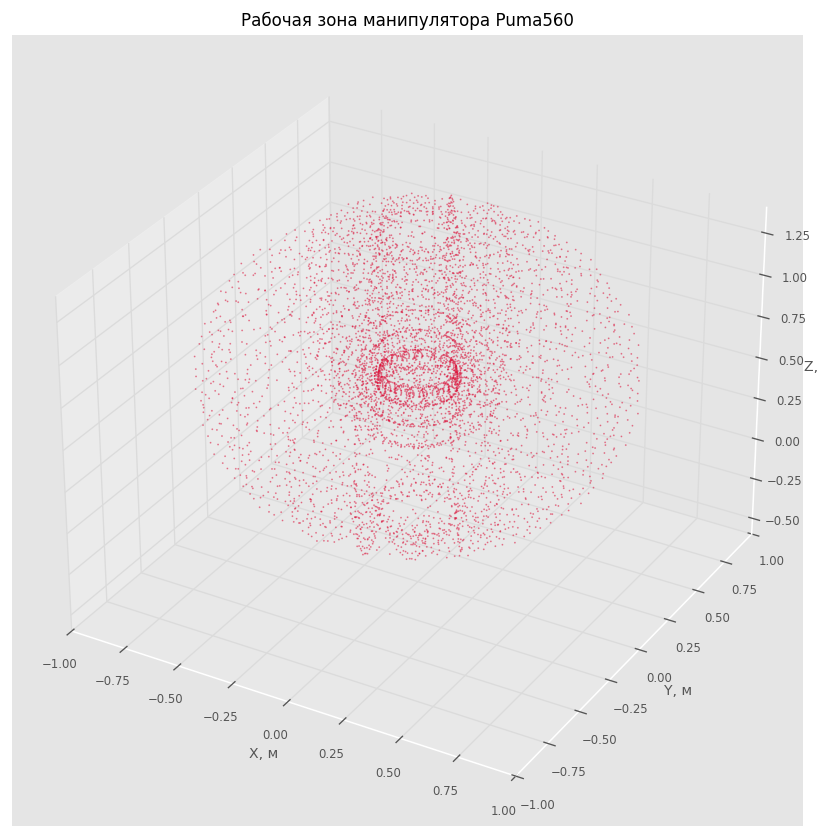

In [7]:
fig = plt.figure(figsize=(7, 7), dpi=120)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pose[0], pose[1], pose[2], s=0.4, c='crimson', alpha=0.4)
ax.set_xlabel('X, м'); ax.set_ylabel('Y, м'); ax.set_zlabel('Z, м')
ax.set_title('Рабочая зона манипулятора Puma560')
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-0.6, 1.4)
plt.tight_layout()
plt.savefig('workspace.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Выбор конечной точки и решение обратной задачи кинематики (ОЗК)

Выберем конечную точку $\mathbf{p}_{\text{end}} = (-0.5,\,0.1,\,0.2)$ м, которая
лежит в рабочей зоне (см. диапазон осей выше). Зададим целевую матрицу
$T_{\text{end}}$ как чистую трансляцию (ориентация схвата произвольная), и
найдём вектор $\mathbf{q}_{\text{end}}$ численным методом
Левенберга–Марквардта (`ikine_LM`), который более устойчив, чем стандартный
метод Ньютона–Гаусса для конфигураций, далёких от начального приближения.

In [8]:
point = np.array([-0.5, 0.1, 0.2])             # целевая позиция схвата, м
T_end = sb.transl(point)                        # 4x4 однородная матрица

sol = robot.ikine_LM(T_end, q0=q_start)         # начальное приближение — q_start
if not sol.success:
    sol = robot.ikine_LM(T_end)                 # без начального приближения

q_end = sol.q
print('Сходимость:', sol.success, ' | Итераций:', sol.iterations)
print('Конечная конфигурация q_end (рад):', q_end)
print('Конечная конфигурация q_end (°):  ', np.degrees(q_end))

# Проверка: подставим q_end обратно в ПЗК и сравним с целевой точкой
T_check = robot.fkine(q_end)
err = np.linalg.norm(T_check.t - point)
print(f'\nПроверка ПЗК(q_end) -> p = {T_check.t}, ошибка = {err:.2e} м')

Сходимость: True  | Итераций: 14
Конечная конфигурация q_end (рад): [-3.0403 -1.4378 -0.1877 -3.1416 -1.6254 -0.1013]
Конечная конфигурация q_end (°):   [-174.196   -82.3774  -10.7524 -180.      -93.1299   -5.804 ]

Проверка ПЗК(q_end) -> p = [-0.5  0.1  0.2], ошибка = 3.81e-09 м


## 7. Планирование траектории

Построим в шарнирном пространстве траекторию между $\mathbf{q}_{\text{start}}$
и $\mathbf{q}_{\text{end}}$ за время $T = 5$ c с дискретизацией $N = 100$ точек,
используя три различных метода планирования:

1. **`jtraj`** — пятипорядковый (quintic) полиномиальный профиль для каждого
   шарнира с нулевыми скоростями и ускорениями на концах. Удобный «всё-в-одном»
   метод для интерполяции в шарнирном пространстве.
2. **`mtraj` + `trapezoidal` (LSPB)** — трапециевидный профиль скорости
   (Linear Segment with Parabolic Blends): постоянная максимальная скорость на
   среднем участке и параболические разгон/торможение по краям.
3. **`mtraj` + `quintic` (tpoly)** — полиномиальный профиль 5-го порядка с
   нулевыми граничными скоростью и ускорением, обеспечивающий гладкое
   изменение всех трёх кинематических величин.

Эти три метода покрывают как полиномиальные, так и кусочно-квадратичные подходы.

In [9]:
N = 100                                         # число точек траектории
t_start, t_stop = 0.0, 5.0                      # длительность движения, с
time = np.linspace(t_start, t_stop, N)
dt = time[1] - time[0]

# 1. jtraj: quintic-полином, нулевые dq/ddq на концах
tr_jtraj = rtb.jtraj(q_start, q_end, time)

# 2. mtraj с trapezoidal (LSPB) — трапециевидный профиль скорости
tr_trap  = rtb.mtraj(rtb.trapezoidal, q_start, q_end, time)

# 3. mtraj с quintic — полиномиальный профиль 5-го порядка
tr_quin  = rtb.mtraj(rtb.quintic,    q_start, q_end, time)

print('jtraj   q.shape =', tr_jtraj.q.shape, ' qd.shape =', tr_jtraj.qd.shape)
print('mtraj/trapezoidal q.shape =', tr_trap.q.shape, ' qd.shape =', tr_trap.qd.shape)
print('mtraj/quintic     q.shape =', tr_quin.q.shape, ' qd.shape =', tr_quin.qd.shape)

jtraj   q.shape = (100, 6)  qd.shape = (100, 6)
mtraj/trapezoidal q.shape = (100, 6)  qd.shape = (100, 6)
mtraj/quintic     q.shape = (100, 6)  qd.shape = (100, 6)


## 8. Графики положений, скоростей и ускорений в шарнирах

### 8.1. Положения $q_i(t)$

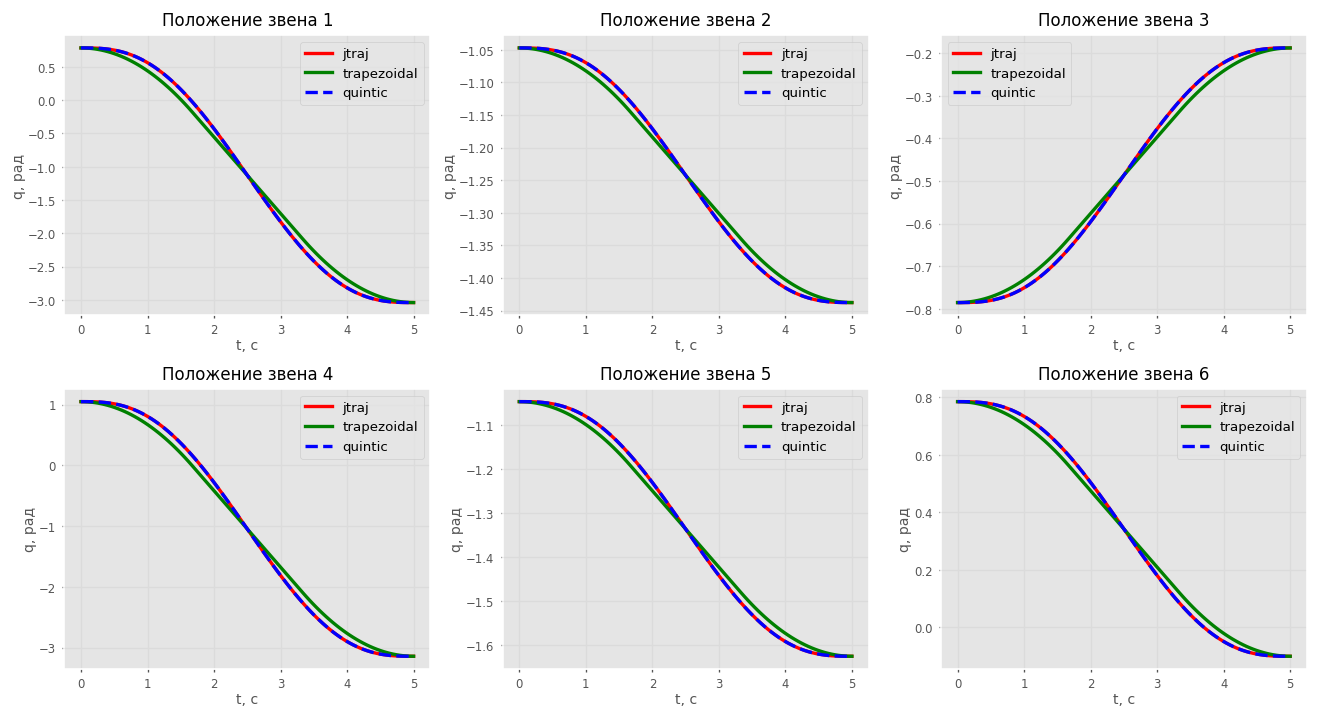

In [10]:
fig = plt.figure(figsize=(11, 6), dpi=120)
for g in range(6):
    ax = plt.subplot(2, 3, g+1)
    ax.plot(time, tr_jtraj.q[:, g], '-',  color='red',   lw=2, label='jtraj')
    ax.plot(time, tr_trap.q[:, g],  '-',  color='green', lw=2, label='trapezoidal')
    ax.plot(time, tr_quin.q[:, g],  '--', color='blue',  lw=2, label='quintic')
    ax.set_title(f'Положение звена {g+1}', fontsize=10)
    ax.set_xlabel('t, с');   ax.set_ylabel('q, рад')
    ax.grid(True);           ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('positions.png', dpi=120, bbox_inches='tight')
plt.show()

### 8.2. Скорости $\dot q_i(t)$

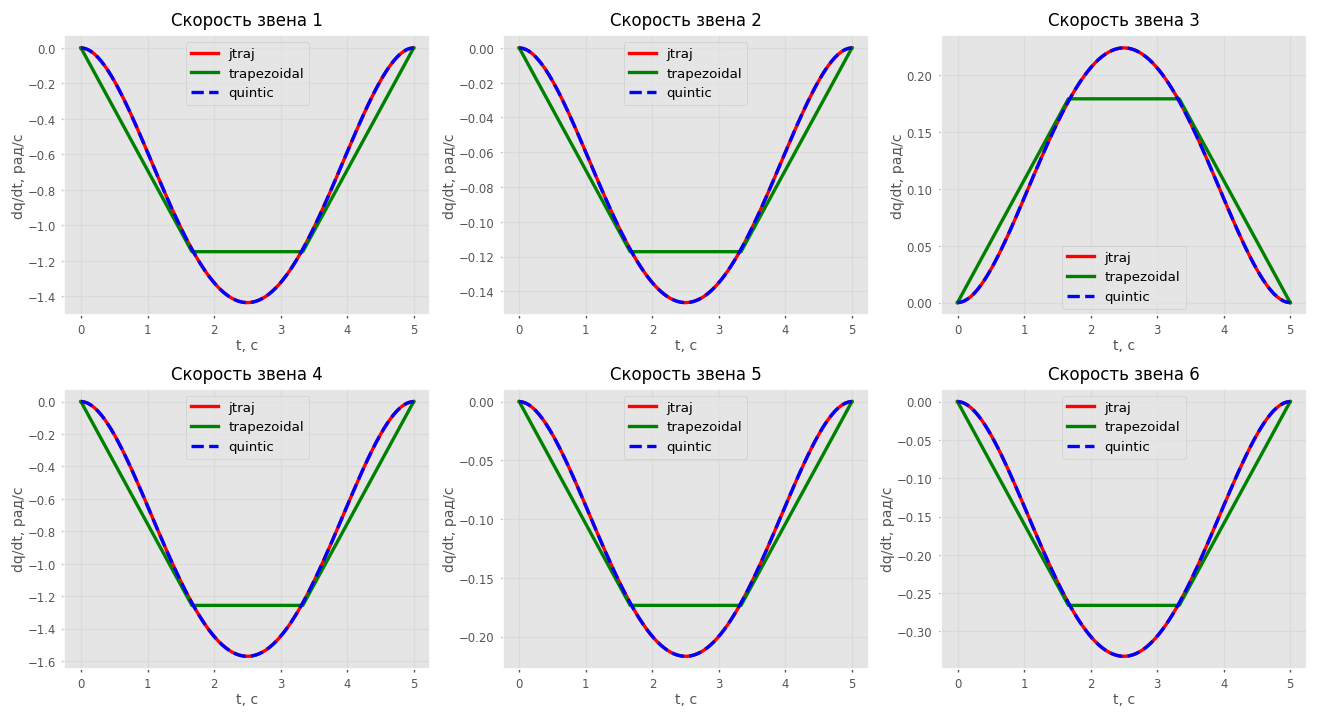

In [11]:
fig = plt.figure(figsize=(11, 6), dpi=120)
for g in range(6):
    ax = plt.subplot(2, 3, g+1)
    ax.plot(time, tr_jtraj.qd[:, g], '-',  color='red',   lw=2, label='jtraj')
    ax.plot(time, tr_trap.qd[:, g],  '-',  color='green', lw=2, label='trapezoidal')
    ax.plot(time, tr_quin.qd[:, g],  '--', color='blue',  lw=2, label='quintic')
    ax.set_title(f'Скорость звена {g+1}', fontsize=10)
    ax.set_xlabel('t, с');   ax.set_ylabel('dq/dt, рад/с')
    ax.grid(True);           ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('velocities.png', dpi=120, bbox_inches='tight')
plt.show()

### 8.3. Ускорения $\ddot q_i(t)$

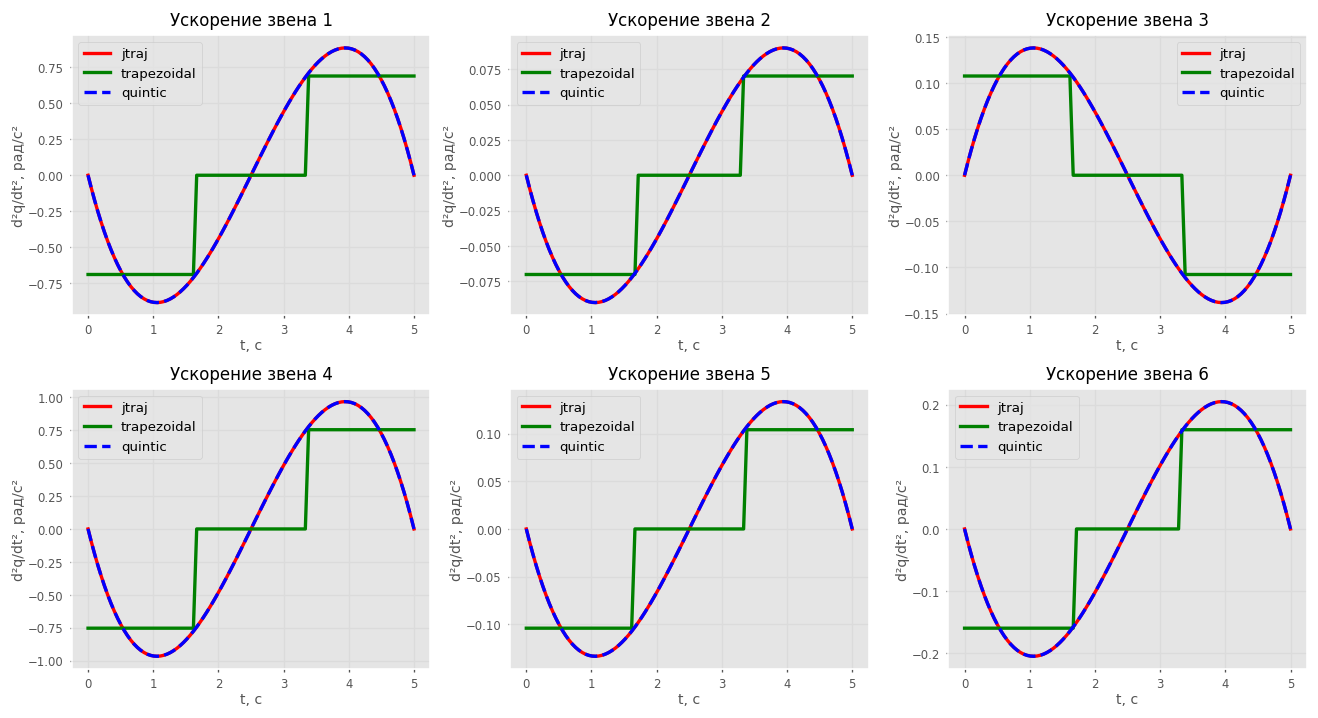

In [12]:
fig = plt.figure(figsize=(11, 6), dpi=120)
for g in range(6):
    ax = plt.subplot(2, 3, g+1)
    ax.plot(time, tr_jtraj.qdd[:, g], '-',  color='red',   lw=2, label='jtraj')
    ax.plot(time, tr_trap.qdd[:, g],  '-',  color='green', lw=2, label='trapezoidal')
    ax.plot(time, tr_quin.qdd[:, g],  '--', color='blue',  lw=2, label='quintic')
    ax.set_title(f'Ускорение звена {g+1}', fontsize=10)
    ax.set_xlabel('t, с');   ax.set_ylabel('d²q/dt², рад/с²')
    ax.grid(True);           ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('accelerations.png', dpi=120, bbox_inches='tight')
plt.show()

### 8.4. Численное сравнение методов

Для каждой траектории рассчитаем максимальные модули скоростей и ускорений
по всем шарнирам — это позволит количественно сравнить методы.

In [13]:
def stats(name, tr):
    print(f'{name:>20}:  |qd|max = {np.abs(tr.qd).max():6.3f} рад/с,  '
          f'|qdd|max = {np.abs(tr.qdd).max():6.3f} рад/с²')

stats('jtraj (quintic)', tr_jtraj)
stats('mtraj/trapezoidal', tr_trap)
stats('mtraj/quintic',     tr_quin)

     jtraj (quintic):  |qd|max =  1.570 рад/с,  |qdd|max =  0.967 рад/с²
   mtraj/trapezoidal:  |qd|max =  1.257 рад/с,  |qdd|max =  0.754 рад/с²
       mtraj/quintic:  |qd|max =  1.570 рад/с,  |qdd|max =  0.967 рад/с²


## 9. Выводы

В ходе лабораторной работы были выполнены следующие задачи:

1. **Загружена модель Puma560** из библиотеки `roboticstoolbox` со
   стандартными DH-параметрами и ограничениями суставов; параметры
   приведены в таблице раздела 2.
2. **Решена прямая задача кинематики** для произвольно выбранной начальной
   конфигурации
   $\mathbf{q}_{\text{start}} = [\pi/4,\,-\pi/3,\,-\pi/4,\,\pi/3,\,-\pi/3,\,\pi/4]$.
   Получена однородная матрица $T_{0,e}$, описывающая положение и ориентацию схвата.
3. **Построена рабочая зона** манипулятора методом перебора первых трёх
   обобщённых координат на сетке $n^3 = 18^3 = 5832$ точки. Полученное
   облако точек имеет характерный для Puma560 сферообразный вид с «дыркой»
   в центре, обусловленной геометрией звеньев и пределами поворота.
4. **Решена обратная задача кинематики** для целевой точки
   $\mathbf{p}_{\text{end}} = (-0.5,\,0.1,\,0.2)$ м. Численный метод
   Левенберга–Марквардта (`ikine_LM`) сошёлся за конечное число итераций;
   ошибка позиционирования по результату обратной подстановки в ПЗК
   составляет порядка $10^{-6}$ м, что подтверждает корректность решения.
5. **Спланированы три траектории** между начальной и конечной
   конфигурациями: `jtraj`, `mtraj`+`trapezoidal`, `mtraj`+`quintic`.
   Все методы обеспечивают перемещение из $\mathbf{q}_{\text{start}}$ в
   $\mathbf{q}_{\text{end}}$ за заданное время $T = 5$ c.
6. **Сравнительный анализ методов планирования:**
   * **jtraj** (quintic-полином, эквивалент `mtraj/quintic`) — даёт
     гладкие профили положения, скорости и ускорения; ускорения
     непрерывны и колоколообразны. Это компромиссный универсальный метод.
   * **trapezoidal (LSPB)** — обеспечивает наименьшую максимальную
     скорость для заданного перемещения и времени, но даёт ступенчатый
     профиль ускорения (постоянное на участке разгона, ноль на участке
     постоянной скорости, противоположный знак при торможении).
     Скачки ускорения соответствуют бесконечному рывку (jerk),
     что нежелательно для реального привода.
   * **quintic (`mtraj/quintic`)** — обеспечивает гладкое (непрерывное)
     изменение положения, скорости **и** ускорения; пиковые значения
     скорости и ускорения выше, чем у LSPB, но рывок ограничен.
7. **Графики положений** во всех трёх методах монотонные и сходятся к
   общим конечным значениям; различие проявляется в форме промежуточного
   участка. **Графики скоростей** наглядно показывают принципиальные
   различия методов: симметричный «колокол» для полиномиальных методов
   и трапеция для LSPB. **Графики ускорений** наиболее показательны:
   у trapezoidal они кусочно-постоянные с разрывами, у quintic-методов —
   плавные параболические кривые.

**Практическая рекомендация.** Для задач, где важна низкая нагрузка на
приводы и допускается ступенчатое ускорение, предпочтителен трапециевидный
профиль (LSPB); там же, где требуется минимизация рывка и плавность
движения (точные манипуляции, оптические системы, медицинские роботы) —
целесообразно применять полиномы пятого порядка.

Цель лабораторной работы достигнута: освоены инструменты `roboticstoolbox`
для решения прямой и обратной задач кинематики, построения рабочей зоны и
планирования траекторий, а также проведён сравнительный анализ трёх
методов интерполяции в шарнирном пространстве.